In [17]:
import pandas as pd
from sklearn.datasets import load_wine

# Load the wine dataset into a DataFrame
wine_data = load_wine(as_frame=True)
wine_df = wine_data.frame

print(wine_df.head())

# Display the shape of the DataFrame
print("Shape of the Wine DataFrame:", wine_df.shape)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

wine = load_wine()
X, y = wine.data, wine.target
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y
print("Shape:", X.shape)
print("Classes:", list(wine.target_names))
df.head()

Shape: (178, 13)
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [19]:
df.drop(columns='target').describe().T[['mean', 'std', 'min', 'max']]
#Wine Dataset basic details


,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


class_0    59
class_1    71
class_2    48
Name: count, dtype: int64


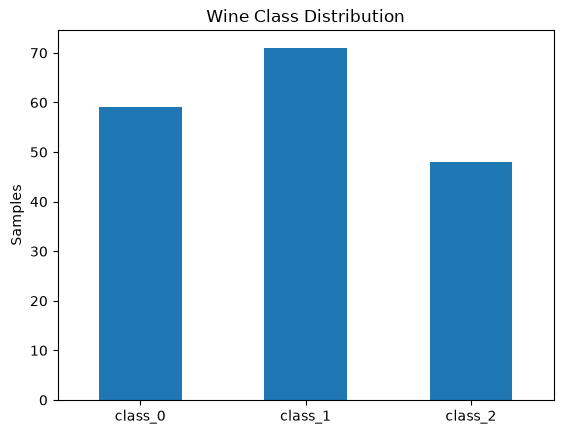

Missing values: 0


In [20]:
# Wine Class distribution
counts = pd.Series(y).map(dict(enumerate(wine.target_names))).value_counts().sort_index()
print(counts)
counts.plot(kind='bar', title='Wine Class Distribution', rot=0)
plt.ylabel('Samples'); plt.show()
print("Missing values:", df.isnull().sum().sum())


#Observations: 

#There are no missing values and there are 3 classes in the dataset. 

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)

#We do the 80-20 split of the dataset into training and testing sets, with stratification to maintain class distribution. The training set contains 80% of the data, while the testing set contains 20%.



Train: (142, 13)  Test: (36, 13)


STEP 2  Implement K-Nearest Neighbhors:


In [22]:
k_values = [1, 5, 11, 15, 21]
knn_acc = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    knn_acc.append(acc)

knn_results = pd.DataFrame({'k': k_values, 'accuracy': knn_acc})
knn_results

,k,accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


Step 3 Implement Radius Neighbor:

In [23]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_acc, no_neighbors = [], []
for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
    rnn.fit(X_train, y_train)
    acc = accuracy_score(y_test, rnn.predict(X_test))
    rnn_acc.append(acc)
    counts_in_radius = [len(n) for n in rnn.radius_neighbors(X_test, return_distance=False)]
    no_neighbors.append(sum(c == 0 for c in counts_in_radius))

rnn_results = pd.DataFrame({'radius': radius_values, 'accuracy': rnn_acc,
                            'test points with no neighbors': no_neighbors})
rnn_results

,radius,accuracy,test points with no neighbors
0,350,0.722222,0
1,400,0.694444,0
2,450,0.694444,0
3,500,0.694444,0
4,550,0.666667,0
5,600,0.666667,0


Step 4: Visualise